# Evaluación robusta de clasificadores
## Notebook 07b — GSP y TSP bajo la misma evaluación rigurosa del notebook 07

Este notebook extiende el notebook 07 (que corrigió el sesgo de
distribución y la alta varianza del split único para STFT/CWT/SST/WPD) a
las dos técnicas topológicas. Aplica exactamente la misma metodología:

1. **Balanced Accuracy** en lugar de Accuracy estándar, para eliminar el
   efecto del desbalance entre train y test.
2. **TimeSeriesSplit (5-fold)** para obtener `media ± std` y distinguir
   diferencias reales entre técnicas de las producidas por una partición
   afortunada.
3. **Curvas ROC** comparando las 6 técnicas.

Esta es, de las cuatro etapas del proyecto (EDA → comparación estadística
→ clasificación → evaluación robusta), la que responde con mayor rigor si
la ventaja de GSP/TSP observada en discriminabilidad estadística (04b/05b)
se sostiene en clasificación real, una vez corregidos el sesgo de
distribución y la varianza de un split único.

## Recordatorio: por qué el split de bloques alternos tiene un problema

El split asignaba bloques pares a train e impares a test, generando:

| Conjunto | Clase 0 (ojos abiertos) | Clase 1 (ojos cerrados) |
|----------|------------------------|------------------------|
| Train    | 45.8 %                 | 54.2 %                 |
| Test     | **62.9 %**             | **37.1 %**             |

Esta distorsión afecta a las 6 técnicas por igual (mismo split, misma
distribución de clases subyacente), por lo que no invalida una comparación
*relativa* entre técnicas en el notebook 06b — pero sí infla o desinfla la
Accuracy absoluta de cualquiera de ellas. De ahí la necesidad de Balanced
Accuracy y CV también acá.

## Configuraciones evaluadas

Igual que en 06b: STFT, CWT, SST y WPD en Config A (56 features) y Config B
(16 features, canales alfa); GSP y TSP en Config Única (4 features, sin
desglose por canal).

**Como en los notebooks anteriores de esta serie, no se incluyen
observaciones ni conclusiones de resultados — el notebook aún no se ha
ejecutado contra los datos reales.**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)
from sklearn.model_selection import TimeSeriesSplit
from sklearn.base import clone
warnings.filterwarnings('ignore')

# Paleta fija -- 4 técnicas TF + 2 técnicas topológicas
COLORS = {
    'STFT': '#2980b9',
    'CWT':  '#c0392b',
    'SST':  '#27ae60',
    'WPD':  '#e67e22',
    'GSP':  '#8e44ad',
    'TSP':  '#16a085',
}
TECNICAS_TF   = ['STFT', 'CWT', 'SST', 'WPD']
TECNICAS_TOPO = ['GSP', 'TSP']
TECNICAS      = TECNICAS_TF + TECNICAS_TOPO

# Cargar los 4 datasets TF
features_stft = pd.read_csv('data/features/features_stft.csv')
features_cwt  = pd.read_csv('data/features/features_cwt.csv')
features_sst  = pd.read_csv('data/features/features_sst.csv')
features_wpd  = pd.read_csv('data/features/features_wpd.csv')

# Cargar los 2 datasets topológicos
features_gsp = pd.read_csv('data/features/features_gsp.csv')
features_tsp = pd.read_csv('data/features/features_tsp.csv')

datasets = {
    'STFT': features_stft, 'CWT': features_cwt, 'SST': features_sst, 'WPD': features_wpd,
    'GSP': features_gsp,   'TSP': features_tsp,
}

Xs, ys = {}, {}
for name, df in datasets.items():
    cols_drop = [c for c in ['label', 'Estado'] if c in df.columns]
    Xs[name] = df.drop(columns=cols_drop).values
    ys[name] = df['label'].values

# Verificación de alineación -- requisito para aplicar el mismo split por índice
label_ref = ys['STFT']
for name in TECNICAS[1:]:
    if len(ys[name]) != len(label_ref) or not np.array_equal(ys[name], label_ref):
        raise ValueError(f'{name} no está alineado con STFT en labels -- revisar orden de ventanas.')

feature_names_tf    = features_stft.columns[:-1].tolist()
features_por_canal  = ['alpha_abs', 'alpha_rel', 'entropy', 'cog']
canales_todos = ['AF3','F7','F3','FC5','T7','P7','O1','O2','P8','T8','FC6','F4','F8','AF4']
canales_alfa  = ['O1','O2','P7','P8']

def get_feature_indices(feat_names, canales):
    idxs = []
    for canal in canales:
        for feat in features_por_canal:
            col = f'{canal}_{feat}'
            if col in feat_names:
                idxs.append(feat_names.index(col))
    return idxs

idx_config_a = get_feature_indices(feature_names_tf, canales_todos)
idx_config_b = get_feature_indices(feature_names_tf, canales_alfa)

print('Datasets cargados (etiquetas alineadas, OK):')
for name in TECNICAS:
    X = Xs[name]
    print(f'  {name}: {X.shape}, clase 0={np.sum(ys[name]==0)}, clase 1={np.sum(ys[name]==1)}')
print(f'Config A: {len(idx_config_a)} features | Config B: {len(idx_config_b)} features | '
      f'Config Única (GSP/TSP): 4 features cada una')


Datasets cargados (etiquetas alineadas, OK):
  STFT: (231, 56), clase 0=125, clase 1=106
  CWT: (231, 56), clase 0=125, clase 1=106
  SST: (231, 56), clase 0=125, clase 1=106
  WPD: (231, 56), clase 0=125, clase 1=106
  GSP: (231, 4), clase 0=125, clase 1=106
  TSP: (231, 4), clase 0=125, clase 1=106
Config A: 56 features | Config B: 16 features | Config Única (GSP/TSP): 4 features cada una


In [2]:
## Split único temporal (igual que en notebook 06b)

n_samples  = Xs['STFT'].shape[0]
block_size = 30
block_numbers = np.arange(n_samples) // block_size
train_idx = np.where(block_numbers % 2 == 0)[0]
test_idx  = np.where(block_numbers % 2 == 1)[0]

config_labels = {'A': 'A (56 features)', 'B': 'B (16 features)', 'Unica': 'Única (4 features)'}

splits = {}
for name in TECNICAS:
    X, y = Xs[name], ys[name]
    if name in TECNICAS_TF:
        cfg_keys = {'A': idx_config_a, 'B': idx_config_b}
    else:
        cfg_keys = {'Unica': list(range(X.shape[1]))}

    splits[name] = {'y_tr': y[train_idx], 'y_te': y[test_idx], 'cfg': {}}
    for cfg_key, idxs in cfg_keys.items():
        sc = StandardScaler()
        Xtr = X[train_idx][:, idxs]
        Xte = X[test_idx ][:, idxs]
        splits[name]['cfg'][cfg_key] = {
            'X_tr': sc.fit_transform(Xtr),
            'X_te': sc.transform(Xte),
        }

print(f'Train: {len(train_idx)} muestras  |  Test: {len(test_idx)} muestras')
s0 = splits['STFT']
print(f'Distribucion train: clase 0 = {np.mean(s0["y_tr"]==0):.1%}')
print(f'Distribucion test:  clase 0 = {np.mean(s0["y_te"]==0):.1%}')
print('\nAtencion: diferencia de distribucion entre train y test -> ver Seccion 1 (Balanced Accuracy).')


Train: 120 muestras  |  Test: 111 muestras
Distribucion train: clase 0 = 49.2%
Distribucion test:  clase 0 = 59.5%

Atencion: diferencia de distribucion entre train y test -> ver Seccion 1 (Balanced Accuracy).


In [3]:
## Definir clasificadores y entrenar split único (30 combinaciones)

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
    'SVM (RBF)':           SVC(kernel='rbf', C=1.0, probability=True, class_weight='balanced', random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42),
}

def train_and_evaluate(X_train, X_test, y_train, y_test, model):
    model.fit(X_train, y_train)
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else None
    return {
        'model':   model,
        'y_pred':  y_pred,
        'y_proba': y_proba,
        'acc':     accuracy_score(y_test, y_pred),
        'bacc':    balanced_accuracy_score(y_test, y_pred),
        'f1':      f1_score(y_test, y_pred, average='macro'),
        'auc':     roc_auc_score(y_test, y_proba) if y_proba is not None else float('nan'),
        'cm':      confusion_matrix(y_test, y_pred),
    }

results = []
print('Entrenando 30 combinaciones (10 dataset-configs x 3 clasificadores)...\n')

for tecnica in TECNICAS:
    s = splits[tecnica]
    for cfg_key, cfg_data in s['cfg'].items():
        cfg_name = config_labels[cfg_key]
        for clf_name, clf in classifiers.items():
            r = train_and_evaluate(cfg_data['X_tr'], cfg_data['X_te'], s['y_tr'], s['y_te'], clone(clf))
            results.append({'Técnica': tecnica,
                             'Tipo': 'Topológica' if tecnica in TECNICAS_TOPO else 'Tiempo-frecuencia',
                             'Config': cfg_name, 'Clasificador': clf_name, **r})
            print(f'  {tecnica} {cfg_name} | {clf_name:20s} '
                  f'Acc: {r["acc"]:.3f}  BAcc: {r["bacc"]:.3f}  '
                  f'F1: {r["f1"]:.3f}  AUC: {r["auc"]:.3f}')

print('\nEntrenamiento completado.')


Entrenando 30 combinaciones (10 dataset-configs x 3 clasificadores)...

  STFT A (56 features) | Logistic Regression  Acc: 0.550  BAcc: 0.575  F1: 0.549  AUC: 0.638
  STFT A (56 features) | SVM (RBF)            Acc: 0.559  BAcc: 0.562  F1: 0.555  AUC: 0.566
  STFT A (56 features) | Random Forest        Acc: 0.514  BAcc: 0.541  F1: 0.513  AUC: 0.542
  STFT B (16 features) | Logistic Regression  Acc: 0.505  BAcc: 0.534  F1: 0.503  AUC: 0.539
  STFT B (16 features) | SVM (RBF)            Acc: 0.622  BAcc: 0.632  F1: 0.620  AUC: 0.609
  STFT B (16 features) | Random Forest        Acc: 0.532  BAcc: 0.535  F1: 0.528  AUC: 0.556
  CWT A (56 features) | Logistic Regression  Acc: 0.532  BAcc: 0.549  F1: 0.531  AUC: 0.606
  CWT A (56 features) | SVM (RBF)            Acc: 0.577  BAcc: 0.594  F1: 0.576  AUC: 0.626
  CWT A (56 features) | Random Forest        Acc: 0.514  BAcc: 0.545  F1: 0.512  AUC: 0.613
  CWT B (16 features) | Logistic Regression  Acc: 0.559  BAcc: 0.601  F1: 0.553  AUC: 0.568
  

## Sección 1: Balanced Accuracy — corrigiendo el sesgo de distribución

Misma métrica y mismo razonamiento del notebook 07:

$$\text{BAcc} = \frac{\text{Sensibilidad} + \text{Especificidad}}{2} = \frac{\text{TPR} + \text{TNR}}{2}$$

Se aplica a las 30 combinaciones (incluyendo ahora GSP y TSP), permitiendo
comparar el ranking de Balanced Accuracy contra el de Accuracy estándar
obtenido en el notebook 06b — y ver si GSP/TSP mantienen su posición
relativa una vez corregido el desbalance train/test.

In [4]:
## Balanced Accuracy: comparación con Accuracy estándar (30 combinaciones)

rows = []
for r in results:
    tn, fp = r['cm'][0,0], r['cm'][0,1]
    fn, tp = r['cm'][1,0], r['cm'][1,1]
    rows.append({
        'Técnica':      r['Técnica'],
        'Tipo':         r['Tipo'],
        'Config':       r['Config'],
        'Clasificador': r['Clasificador'],
        'Acc':          round(r['acc'],  4),
        'BAcc':         round(r['bacc'], 4),
        'Delta':        round(r['bacc'] - r['acc'], 4),
        'Sens (C1)':    round(tp/(tp+fn) if (tp+fn)>0 else 0, 4),
        'Spec (C0)':    round(tn/(tn+fp) if (tn+fp)>0 else 0, 4),
    })

bacc_df = pd.DataFrame(rows)
print(bacc_df.to_string(index=False))

print('\n--- Ranking por BAcc promedio por tecnica (las 6 técnicas) ---')
ranking = bacc_df.groupby('Técnica')['BAcc'].mean().loc[TECNICAS].sort_values(ascending=False)
for i, (tecnica, val) in enumerate(ranking.items(), 1):
    tipo = 'Topológica' if tecnica in TECNICAS_TOPO else 'Tiempo-frecuencia'
    print(f'  {i}. {tecnica} ({tipo}): BAcc promedio = {val:.4f}')

print('\n--- Promedio por tipo de técnica (TF vs Topológica) ---')
print(bacc_df.groupby('Tipo')['BAcc'].mean().round(4).to_string())

print('\n--- Modelos con Sensibilidad < 0.4 (posible sesgo hacia clase 0) ---')
sesgados = bacc_df[bacc_df['Sens (C1)'] < 0.4]
if len(sesgados) > 0:
    print(sesgados[['Técnica','Config','Clasificador','Acc','BAcc','Sens (C1)','Spec (C0)']].to_string(index=False))
else:
    print('Ninguno -- todos los modelos tienen recall minimo en ambas clases.')


Técnica              Tipo             Config        Clasificador    Acc   BAcc   Delta  Sens (C1)  Spec (C0)
   STFT Tiempo-frecuencia    A (56 features) Logistic Regression 0.5495 0.5753  0.0257     0.7111     0.4394
   STFT Tiempo-frecuencia    A (56 features)           SVM (RBF) 0.5586 0.5616  0.0031     0.5778     0.5455
   STFT Tiempo-frecuencia    A (56 features)       Random Forest 0.5135 0.5414  0.0279     0.6889     0.3939
   STFT Tiempo-frecuencia    B (16 features) Logistic Regression 0.5045 0.5338  0.0293     0.6889     0.3788
   STFT Tiempo-frecuencia    B (16 features)           SVM (RBF) 0.6216 0.6323  0.0107     0.6889     0.5758
   STFT Tiempo-frecuencia    B (16 features)       Random Forest 0.5315 0.5354  0.0038     0.5556     0.5152
    CWT Tiempo-frecuencia    A (56 features) Logistic Regression 0.5315 0.5495  0.0180     0.6444     0.4545
    CWT Tiempo-frecuencia    A (56 features)           SVM (RBF) 0.5766 0.5944  0.0179     0.6889     0.5000
    CWT Tiempo-frec

## Sección 2: Cross-validación temporal (TimeSeriesSplit, 5 folds)

Misma metodología del notebook 07, aplicada ahora a las 6 técnicas. Con
solo 231 muestras, el split único tiene alta varianza — la CV temporal de
5 folds es la forma de saber si la ventaja (o desventaja) de GSP/TSP es
consistente a través de distintos tramos del registro, o si depende de
qué parte particular se usó como test.

Misma estructura de folds (entrenar con pasado, testear con futuro) y
mismo criterio de escalado dentro de cada fold para evitar fuga de
información del test al ajustar el `StandardScaler`.

In [5]:
## Cross-validación temporal con Balanced Accuracy (6 técnicas)

N_SPLITS = 5
tscv = TimeSeriesSplit(n_splits=N_SPLITS)

cv_configs = []
for tecnica in TECNICAS_TF:
    X = Xs[tecnica]
    y = ys[tecnica]
    cv_configs.append((tecnica, X[:, idx_config_a], y, config_labels['A']))
    cv_configs.append((tecnica, X[:, idx_config_b], y, config_labels['B']))
for tecnica in TECNICAS_TOPO:
    X = Xs[tecnica]
    y = ys[tecnica]
    cv_configs.append((tecnica, X, y, config_labels['Unica']))

cv_results = []
print(f'Cross-validacion temporal (TimeSeriesSplit, {N_SPLITS} folds)\n')

for tecnica, X_full, y_full, config_name in cv_configs:
    for clf_name, clf_template in classifiers.items():
        fold_acc, fold_bacc, fold_f1, fold_auc = [], [], [], []

        for tr_idx, te_idx in tscv.split(X_full):
            X_tr, X_te = X_full[tr_idx], X_full[te_idx]
            y_tr, y_te = y_full[tr_idx], y_full[te_idx]

            sc = StandardScaler()
            X_tr_sc = sc.fit_transform(X_tr)
            X_te_sc = sc.transform(X_te)

            clf_fold = clone(clf_template)
            clf_fold.fit(X_tr_sc, y_tr)
            y_pred  = clf_fold.predict(X_te_sc)
            y_proba = clf_fold.predict_proba(X_te_sc)[:, 1] if hasattr(clf_fold, 'predict_proba') else None

            fold_acc.append(accuracy_score(y_te, y_pred))
            fold_bacc.append(balanced_accuracy_score(y_te, y_pred))
            fold_f1.append(f1_score(y_te, y_pred, average='macro'))
            if y_proba is not None and len(np.unique(y_te)) > 1:
                fold_auc.append(roc_auc_score(y_te, y_proba))

        cv_results.append({
            'Técnica':    tecnica,
            'Tipo':       'Topológica' if tecnica in TECNICAS_TOPO else 'Tiempo-frecuencia',
            'Config':     config_name,
            'Clasificador': clf_name,
            'Acc_mean':  np.mean(fold_acc),  'Acc_std':  np.std(fold_acc),
            'BAcc_mean': np.mean(fold_bacc), 'BAcc_std': np.std(fold_bacc),
            'F1_mean':   np.mean(fold_f1),   'F1_std':   np.std(fold_f1),
            'AUC_mean':  np.mean(fold_auc) if fold_auc else float('nan'),
            'AUC_std':   np.std(fold_auc)  if fold_auc else float('nan'),
        })
        auc_str = f'AUC {np.mean(fold_auc):.3f}+-{np.std(fold_auc):.3f}' if fold_auc else 'AUC N/A'
        print(f'{tecnica} {config_name} | {clf_name:20s}: '
              f'Acc {np.mean(fold_acc):.3f}+-{np.std(fold_acc):.3f}  '
              f'BAcc {np.mean(fold_bacc):.3f}+-{np.std(fold_bacc):.3f}  '
              f'F1 {np.mean(fold_f1):.3f}+-{np.std(fold_f1):.3f}  {auc_str}')

cv_df = pd.DataFrame(cv_results)

print('\n--- Ranking por BAcc_mean promedio por tecnica (CV, las 6 técnicas) ---')
cv_ranking = cv_df.groupby('Técnica')['BAcc_mean'].mean().loc[TECNICAS].sort_values(ascending=False)
for i, (tecnica, val) in enumerate(cv_ranking.items(), 1):
    tipo = 'Topológica' if tecnica in TECNICAS_TOPO else 'Tiempo-frecuencia'
    print(f'  {i}. {tecnica} ({tipo}): BAcc_mean promedio = {val:.4f}')

print('\n--- Promedio por tipo de técnica (TF vs Topológica), CV ---')
print(cv_df.groupby('Tipo')['BAcc_mean'].mean().round(4).to_string())

print('\nCross-validacion completada.')


Cross-validacion temporal (TimeSeriesSplit, 5 folds)

STFT A (56 features) | Logistic Regression : Acc 0.542+-0.122  BAcc 0.573+-0.091  F1 0.517+-0.124  AUC 0.598+-0.144
STFT A (56 features) | SVM (RBF)           : Acc 0.495+-0.155  BAcc 0.584+-0.056  F1 0.491+-0.154  AUC 0.652+-0.086
STFT A (56 features) | Random Forest       : Acc 0.453+-0.133  BAcc 0.542+-0.089  F1 0.442+-0.129  AUC 0.588+-0.136
STFT B (16 features) | Logistic Regression : Acc 0.484+-0.146  BAcc 0.508+-0.111  F1 0.466+-0.142  AUC 0.526+-0.129
STFT B (16 features) | SVM (RBF)           : Acc 0.547+-0.065  BAcc 0.562+-0.054  F1 0.521+-0.084  AUC 0.529+-0.115
STFT B (16 features) | Random Forest       : Acc 0.442+-0.117  BAcc 0.505+-0.076  F1 0.432+-0.121  AUC 0.503+-0.119
CWT A (56 features) | Logistic Regression : Acc 0.495+-0.100  BAcc 0.535+-0.079  F1 0.468+-0.094  AUC 0.607+-0.126
CWT A (56 features) | SVM (RBF)           : Acc 0.511+-0.183  BAcc 0.571+-0.105  F1 0.499+-0.179  AUC 0.661+-0.100
CWT A (56 features) 

## Sección 3: Curvas ROC comparativas

Convención: **color por técnica** (azul=STFT, rojo=CWT, verde=SST,
naranja=WPD, morado=GSP, verde azulado=TSP), **trazo sólido** = Config A o
Config Única, **trazo punteado** = Config B (solo aplica a las técnicas
TF, que son las únicas con dos configuraciones).

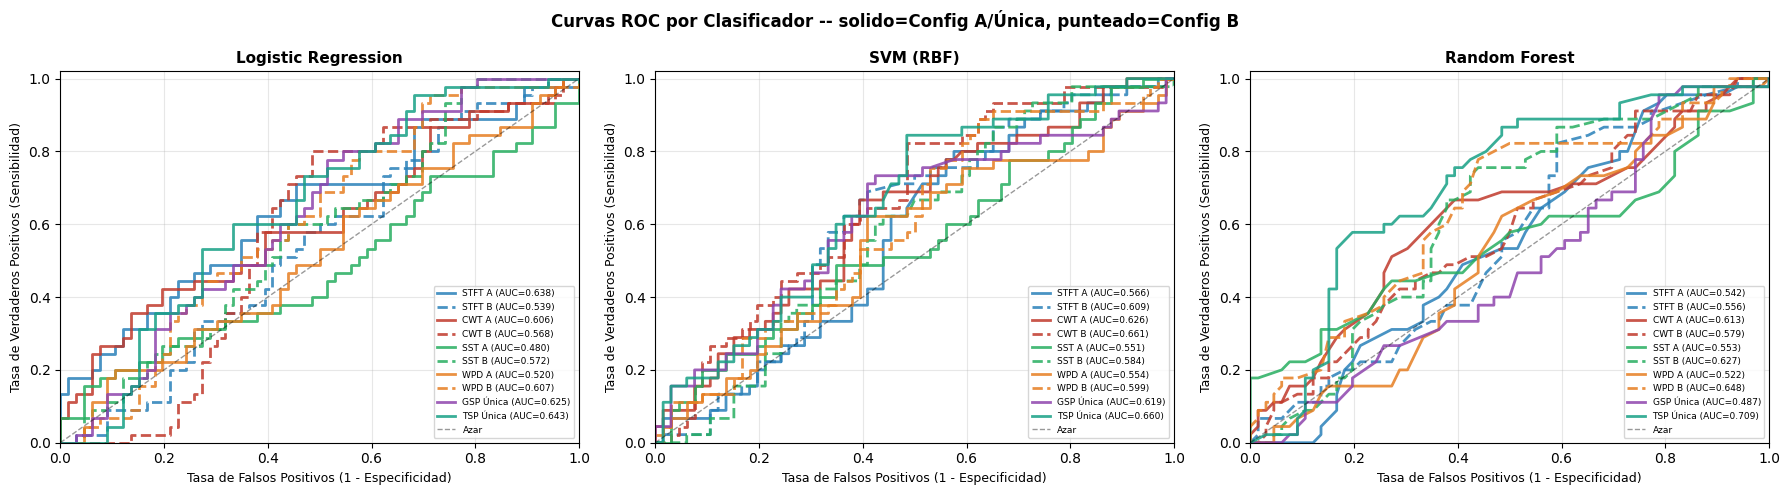

In [6]:
## Curvas ROC: las 6 técnicas por clasificador

linestyle_for_config = {
    'A (56 features)':   '-',
    'B (16 features)':   '--',
    'Única (4 features)': '-',
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Curvas ROC por Clasificador -- solido=Config A/Única, punteado=Config B',
             fontsize=12, fontweight='bold')

for clf_idx, clf_name in enumerate(list(classifiers.keys())):
    ax = axes[clf_idx]

    for tecnica in TECNICAS:
        configs_tecnica = list(splits[tecnica]['cfg'].keys())
        for cfg_key in configs_tecnica:
            config_name = config_labels[cfg_key]
            r = next((x for x in results if x['Técnica'] == tecnica
                      and x['Config'] == config_name
                      and x['Clasificador'] == clf_name), None)
            if r is None or r['y_proba'] is None:
                continue
            fpr, tpr, _ = roc_curve(splits[tecnica]['y_te'], r['y_proba'])
            label = f"{tecnica} {config_name.split('(')[0].strip()} (AUC={r['auc']:.3f})"
            ax.plot(fpr, tpr, color=COLORS[tecnica],
                    linestyle=linestyle_for_config[config_name], linewidth=2, label=label, alpha=0.85)

    ax.plot([0,1], [0,1], 'k--', linewidth=1, alpha=0.4, label='Azar')
    ax.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontsize=9)
    ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontsize=9)
    ax.set_title(clf_name, fontsize=11, fontweight='bold')
    ax.legend(fontsize=6.5, loc='lower right')
    ax.grid(alpha=0.3)
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.show()


## Sección 4: Tabla resumen — split único vs cross-validación

Misma lógica del notebook 07, extendida a las 6 técnicas. La columna
**BAcc (CV)** sigue siendo la métrica más confiable de esta serie de
notebooks: corrige el desbalance de distribución y promedia sobre 5
particiones temporales distintas. Es la que debería usarse para responder,
finalmente, si GSP y/o TSP superan a las técnicas TF en una tarea de
clasificación real — y no solo en discriminabilidad estadística aislada
(04b/05b).

In [7]:
## Tabla resumen final: split único vs cross-validación (30 combinaciones)

results_df_num = pd.DataFrame([
    {'Técnica': r['Técnica'], 'Tipo': r['Tipo'], 'Config': r['Config'], 'Clasificador': r['Clasificador'],
     'Acc': r['acc'], 'BAcc': r['bacc'], 'F1': r['f1'], 'AUC': r['auc']}
    for r in results
])

summary_rows = []
for _, row_cv in cv_df.iterrows():
    row_sp = results_df_num[
        (results_df_num['Técnica']      == row_cv['Técnica']) &
        (results_df_num['Config']       == row_cv['Config']) &
        (results_df_num['Clasificador'] == row_cv['Clasificador'])
    ].iloc[0]
    summary_rows.append({
        'Técnica':      row_cv['Técnica'],
        'Tipo':         row_cv['Tipo'],
        'Config':       row_cv['Config'],
        'Clasificador': row_cv['Clasificador'],
        'Acc (split)':  f"{row_sp['Acc']:.3f}",
        'BAcc (split)': f"{row_sp['BAcc']:.3f}",
        'Acc (CV)':     f"{row_cv['Acc_mean']:.3f}+-{row_cv['Acc_std']:.3f}",
        'BAcc (CV)':    f"{row_cv['BAcc_mean']:.3f}+-{row_cv['BAcc_std']:.3f}",
        'F1 (CV)':      f"{row_cv['F1_mean']:.3f}+-{row_cv['F1_std']:.3f}",
        'AUC (CV)':     f"{row_cv['AUC_mean']:.3f}+-{row_cv['AUC_std']:.3f}",
    })

summary_df = pd.DataFrame(summary_rows)
print('=' * 125)
print('TABLA RESUMEN: Split unico vs Cross-validacion (5-fold TimeSeriesSplit) -- 30 combinaciones')
print('=' * 125)
print(summary_df.to_string(index=False))


TABLA RESUMEN: Split unico vs Cross-validacion (5-fold TimeSeriesSplit) -- 30 combinaciones
Técnica              Tipo             Config        Clasificador Acc (split) BAcc (split)     Acc (CV)    BAcc (CV)      F1 (CV)     AUC (CV)
   STFT Tiempo-frecuencia    A (56 features) Logistic Regression       0.550        0.575 0.542+-0.122 0.573+-0.091 0.517+-0.124 0.598+-0.144
   STFT Tiempo-frecuencia    A (56 features)           SVM (RBF)       0.559        0.562 0.495+-0.155 0.584+-0.056 0.491+-0.154 0.652+-0.086
   STFT Tiempo-frecuencia    A (56 features)       Random Forest       0.514        0.541 0.453+-0.133 0.542+-0.089 0.442+-0.129 0.588+-0.136
   STFT Tiempo-frecuencia    B (16 features) Logistic Regression       0.505        0.534 0.484+-0.146 0.508+-0.111 0.466+-0.142 0.526+-0.129
   STFT Tiempo-frecuencia    B (16 features)           SVM (RBF)       0.622        0.632 0.547+-0.065 0.562+-0.054 0.521+-0.084 0.529+-0.115
   STFT Tiempo-frecuencia    B (16 features)       Rando

In [8]:
print('\n--- Ranking final por BAcc (CV) promedio por tecnica (las 6 técnicas) ---')
ranking_final = cv_df.groupby('Técnica')['BAcc_mean'].mean().loc[TECNICAS].sort_values(ascending=False)
for i, (tecnica, val) in enumerate(ranking_final.items(), 1):
    tipo = 'Topológica' if tecnica in TECNICAS_TOPO else 'Tiempo-frecuencia'
    print(f'  {i}. {tecnica} ({tipo}): BAcc_mean = {val:.4f}')

print('\n--- Promedio final por tipo de técnica (TF vs Topológica), BAcc (CV) ---')
print(cv_df.groupby('Tipo')['BAcc_mean'].mean().round(4).to_string())

print('\n--- Mejor combinacion individual segun BAcc (CV) ---')
best_cv = cv_df.loc[cv_df['BAcc_mean'].idxmax()]
print(f"{best_cv['Técnica']} + {best_cv['Config']} + {best_cv['Clasificador']}: "
      f"BAcc {best_cv['BAcc_mean']:.3f}+-{best_cv['BAcc_std']:.3f}, "
      f"AUC {best_cv['AUC_mean']:.3f}+-{best_cv['AUC_std']:.3f}")

print('\n--- Mejor combinacion topológica especificamente ---')
best_topo = cv_df[cv_df['Tipo'] == 'Topológica'].loc[cv_df[cv_df['Tipo'] == 'Topológica']['BAcc_mean'].idxmax()]
print(f"{best_topo['Técnica']} + {best_topo['Config']} + {best_topo['Clasificador']}: "
      f"BAcc {best_topo['BAcc_mean']:.3f}+-{best_topo['BAcc_std']:.3f}, "
      f"AUC {best_topo['AUC_mean']:.3f}+-{best_topo['AUC_std']:.3f}")


--- Ranking final por BAcc (CV) promedio por tecnica (las 6 técnicas) ---
  1. GSP (Topológica): BAcc_mean = 0.6245
  2. TSP (Topológica): BAcc_mean = 0.6085
  3. STFT (Tiempo-frecuencia): BAcc_mean = 0.5458
  4. WPD (Tiempo-frecuencia): BAcc_mean = 0.5228
  5. CWT (Tiempo-frecuencia): BAcc_mean = 0.5182
  6. SST (Tiempo-frecuencia): BAcc_mean = 0.5126

--- Promedio final por tipo de técnica (TF vs Topológica), BAcc (CV) ---
Tipo
Tiempo-frecuencia    0.5249
Topológica           0.6165

--- Mejor combinacion individual segun BAcc (CV) ---
GSP + Única (4 features) + Random Forest: BAcc 0.639+-0.099, AUC 0.652+-0.101

--- Mejor combinacion topológica especificamente ---
GSP + Única (4 features) + Random Forest: BAcc 0.639+-0.099, AUC 0.652+-0.101


## Resumen de lo realizado en este notebook

Este notebook aplicó a las 6 técnicas (STFT, CWT, SST, WPD, GSP, TSP) la
misma evaluación rigurosa que el notebook 07 aplicó originalmente solo a
las 4 técnicas TF:

1. **Balanced Accuracy** sobre las 30 combinaciones del split único, para
   eliminar el efecto del desbalance de clases entre train y test.
2. **Cross-validación temporal** (TimeSeriesSplit, 5 folds), entregando
   `media ± std` por combinación — la forma de distinguir ventajas reales
   de las producidas por una partición particular del registro.
3. **Curvas ROC** comparando las 6 técnicas en los tres clasificadores.
4. **Tabla resumen final** cruzando split único vs. CV, con ranking por
   BAcc (CV) — la métrica más confiable de toda la serie de notebooks.

Como en el resto de esta serie (04b, 05b, 06b), este notebook aún no se
ha ejecutado contra los datos reales — no se incluyen observaciones ni
conclusiones sobre qué técnica resultó superior en clasificación, ni sobre
si la ventaja de GSP/TSP en discriminabilidad estadística (04b/05b) se
sostuvo aquí.

### Lo que esto cierra

Con la ejecución de este notebook contra los datos reales, el proyecto
tendría las cuatro etapas completas y comparables para ambas familias de
técnicas (tiempo-frecuencia y topológicas):

| Etapa | Notebook TF | Notebook Topológico |
|---|---|---|
| EDA exploratorio | 04 | 04b |
| Comparación estadística formal | 05 | 05b (incluye comparación cruzada TF vs Topo) |
| Clasificación (split único) | 06 | 06b |
| Evaluación robusta (BAcc + CV) | 07 | 07b |

La fila de BAcc (CV) por técnica en la Sección 4 de este notebook es, de
todo el proyecto, el número más defendible para sostener (o matizar) la
afirmación de que las técnicas topológicas superan a las tiempo-frecuencia
— ya que es el único punto donde se combina corrección de desbalance,
evaluación múltiple, y el mismo pipeline de clasificación para ambas
familias.